## Notebook 04 — Inferential Analyses

Project: Ten-Year Haemoglobin Genotype Surveillance in a Nigerian University Cohort (Bowen University, 2015–2024, n = 8,890)

### Purpose

This notebook performs the study’s inferential analyses and generates the corresponding statistical figures. The analyses include ordinary least squares (OLS) regression of genotype and clinical-category frequencies over time, together with chi-square tests of association between sex and both genotype and clinical category.

Regression outputs, statistical summaries, and figures are exported using the project’s established naming conventions and visual style.

### Outputs

The notebook produces:

* OLS trend regression for HbAA, HbAS, HbAC, Carrier (HbAS + HbAC), and Disease (HbSS + HbSC + HbCC), including slope, R², p-value, and significance
* Chi-square tests of association for sex × genotype and sex × clinical category
* Six statistical figures
* Exported tables with the `04_` prefix


## Cell 1 - Environment and shared settings

In [1]:
# Cell 1: Environment and shared settings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

GENO_COLOR = {
    "AA": "#1f77b4", "AC": "#2ca02c", "AS": "#ff7f0e",
    "CC": "#8c564b", "SC": "#9467bd", "SS": "#d62728",
}
CLIN_COLOR = {"Normal": "#1f77b4", "Carrier": "#ff7f0e", "Disease": "#d62728"}
SEX_COLOR  = {"Male": "#1f77b4", "Female": "#ff7f0e"}

GENO_ORDER = ["AA", "AC", "AS", "CC", "SC", "SS"]
CLIN_ORDER = ["Normal", "Carrier", "Disease"]
YEARS = list(range(2015, 2025))

ALPHA = 0.05   # significance threshold
print("Environment ready.")

Environment ready.


## Cell 2 - Load data and tables

In [2]:
# Cell 2: Load the processed analytical dataset and the descriptive tables from
# Notebook 02 that feed the trend regressions.
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "processed_genotype_data.csv",
                 dtype={"ID": str, "Sex": str, "Genotype": str, "Clinical_Category": str})
df["Year"] = df["Year"].astype(int)

geno_pct_year = pd.read_csv(TABLES / "02_genotype_percentages_by_year.csv", index_col=0)
clin_pct_year = pd.read_csv(TABLES / "02_clinical_category_percentages_by_year.csv",
                            index_col=0)
sex_pct_year  = pd.read_csv(TABLES / "02_sex_percentages_by_year.csv", index_col=0)

print(f"Loaded {len(df):,} records and the descriptive tables.")

Loaded 8,890 records and the descriptive tables.


## Cell 3 - Saving helper

In [3]:
# Cell 3: Save figures as 300 DPI PNG and vector PDF
def save_figure(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")
    print(f"Saved: outputs/figures/{name}.png and .pdf")

## Cell 4 - OLS linear regression of trends

A simple linear regression of percentage against year for each category, using
`scipy.stats.linregress`. Reported quantities: slope (annual rate of change in percentage
points), R-squared, and the two-sided p-value for the slope. Non-significance at the
0.05 level is the consistent finding across all categories.

In [4]:
# Cell 4: OLS trend regression
def regress(years, pct):
    res = stats.linregress(years, pct)
    return {
        "Slope_pp_per_year": res.slope,
        "R_squared": res.rvalue ** 2,
        "p_value": res.pvalue,
        "Significant_at_0.05": res.pvalue < ALPHA,
    }

years_arr = np.array(YEARS)

trend_rows = []
for label, series in [
    ("HbAA",                 geno_pct_year["AA"].reindex(YEARS).values),
    ("HbAS",                 geno_pct_year["AS"].reindex(YEARS).values),
    ("HbAC",                 geno_pct_year["AC"].reindex(YEARS).values),
    ("Carrier (HbAS+HbAC)",  clin_pct_year["Carrier"].reindex(YEARS).values),
    ("Disease (HbSS+HbSC+HbCC)", clin_pct_year["Disease"].reindex(YEARS).values),
    ("Normal (HbAA)",        clin_pct_year["Normal"].reindex(YEARS).values),
]:
    r = regress(years_arr, series)
    r["Category"] = label
    trend_rows.append(r)

trend_results = pd.DataFrame(trend_rows)[
    ["Category", "Slope_pp_per_year", "R_squared", "p_value", "Significant_at_0.05"]
]
trend_results["Slope_pp_per_year"] = trend_results["Slope_pp_per_year"].round(4)
trend_results["R_squared"]         = trend_results["R_squared"].round(4)
trend_results["p_value"]           = trend_results["p_value"].round(4)

display(trend_results)
trend_results.to_csv(TABLES / "04_trend_regression_results.csv", index=False)
print("Saved: outputs/tables/04_trend_regression_results.csv")

,Category,Slope_pp_per_year,R_squared,p_value,Significant_at_0.05
0,HbAA,0.3086,0.1607,0.2510,False
1,HbAS,-0.1744,0.0565,0.5085,False
2,HbAC,-0.1042,0.2742,0.1203,False
3,Carrier (HbAS+HbAC),-0.2780,0.1299,0.3063,False
4,Disease (HbSS+HbSC+HbCC),-0.0301,0.0710,0.4568,False
5,Normal (HbAA),0.3086,0.1607,0.2510,False


Saved: outputs/tables/04_trend_regression_results.csv


## Cell 5 - Chi-square tests of association

Two chi-square tests of independence: sex against genotype (six levels, df = 5) and sex
against clinical category (three levels, df = 2). Reported quantities: chi-square
statistic, degrees of freedom, p-value, and the conclusion at the 0.05 level. Both tests
return non-significant results, consistent with sex-independence of the genotype
distribution.

In [5]:
# Cell 5: Chi-square tests
def chi_square(rows, cols, alpha=ALPHA):
    ct = pd.crosstab(rows, cols)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    return {
        "Chi_square_statistic": chi2,
        "Degrees_of_freedom": dof,
        "p_value": p,
        "Significant_at_0.05": p < alpha,
        "Conclusion": "Statistically significant association" if p < alpha
                       else "No statistically significant association found",
    }

chi_geno = chi_square(df["Sex"], df["Genotype"])
chi_clin = chi_square(df["Sex"], df["Clinical_Category"])

chi_results = pd.DataFrame([
    {"Test": "Sex x Genotype",          **chi_geno},
    {"Test": "Sex x Clinical Category", **chi_clin},
])
chi_results["Chi_square_statistic"] = chi_results["Chi_square_statistic"].round(4)
chi_results["p_value"]              = chi_results["p_value"].round(4)

display(chi_results)
chi_results.to_csv(TABLES / "04_chi_square_results.csv", index=False)
print("Saved: outputs/tables/04_chi_square_results.csv")

,Test,Chi_square_statistic,Degrees_of_freedom,p_value,Significant_at_0.05,Conclusion
0,Sex x Genotype,1.4864,5,0.9146,False,No statistically significant association found
1,Sex x Clinical Category,0.3891,2,0.8232,False,No statistically significant association found


Saved: outputs/tables/04_chi_square_results.csv


## Cell 6 - clinical_category_trends.png

Saved: outputs/figures/clinical_category_trends.png and .pdf


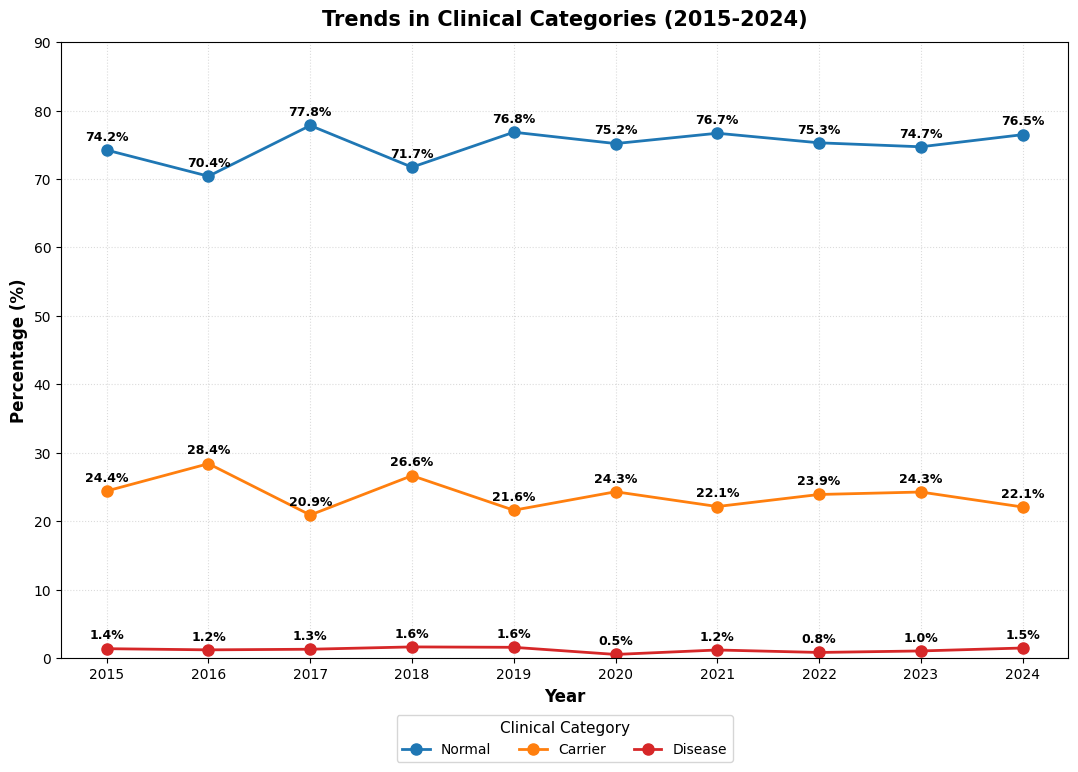

In [6]:
# Cell 6: Clinical-category trend figure (line plot with value labels)
fig, ax = plt.subplots(figsize=(13, 8))

for c in CLIN_ORDER:
    vals = clin_pct_year[c].reindex(YEARS).values
    ax.plot(YEARS, vals, marker="o", linewidth=2.0, markersize=8,
            color=CLIN_COLOR[c], label=c)
    for x, y in zip(YEARS, vals):
        ax.text(x, y + 1.0, f"{y:.1f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

ax.set_title("Trends in Clinical Categories (2015-2024)", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(YEARS)
ax.set_ylim(0, 90)
ax.legend(title="Clinical Category", loc="lower center",
          bbox_to_anchor=(0.5, -0.18), ncol=3)
ax.grid(True, linestyle=":", alpha=0.45)
ax.set_axisbelow(True)

save_figure(fig, "clinical_category_trends")
plt.show()

## Cell 7 - genotype_trends_over_time.png

Saved: outputs/figures/genotype_trends_over_time.png and .pdf


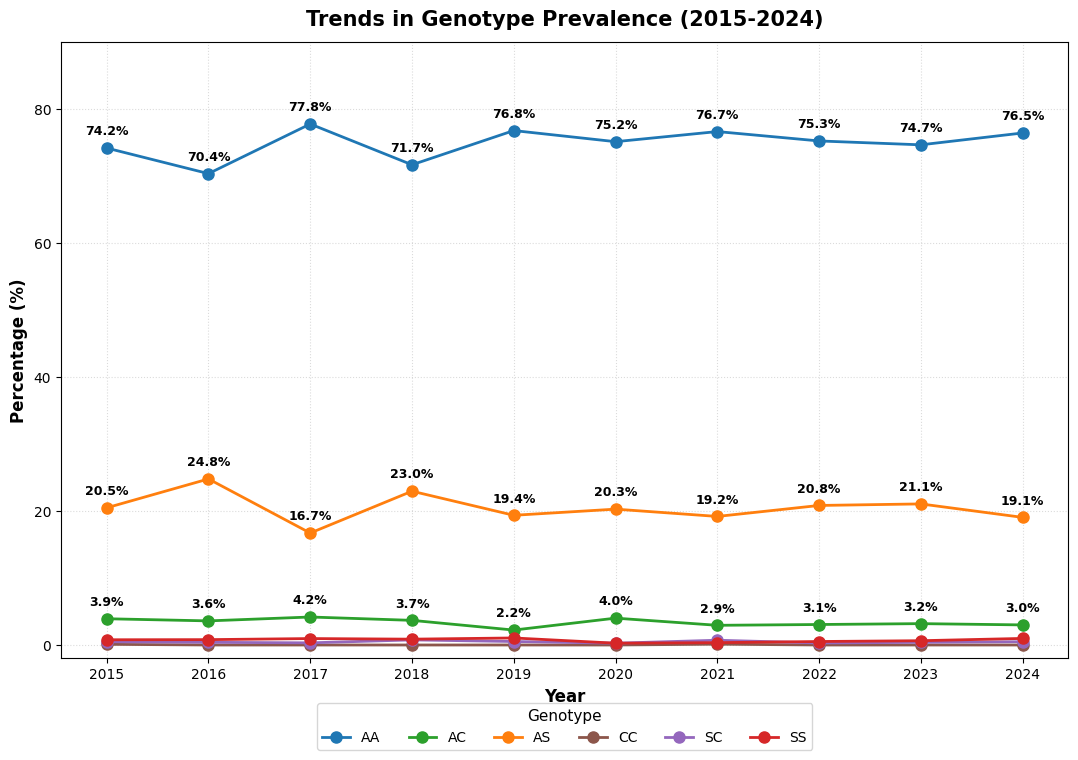

In [7]:
# Cell 7: Genotype trend figure (all six genotypes)
fig, ax = plt.subplots(figsize=(13, 8))

for g in GENO_ORDER:
    vals = geno_pct_year[g].reindex(YEARS).values
    ax.plot(YEARS, vals, marker="o", linewidth=2.0, markersize=8,
            color=GENO_COLOR[g], label=g)
    if g in ("AA", "AS", "AC"):
        for x, y in zip(YEARS, vals):
            ax.text(x, y + 1.5, f"{y:.1f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold")

ax.set_title("Trends in Genotype Prevalence (2015-2024)", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(YEARS)
ax.set_ylim(-2, 90)
ax.legend(title="Genotype", loc="lower center",
          bbox_to_anchor=(0.5, -0.16), ncol=6)
ax.grid(True, linestyle=":", alpha=0.45)
ax.set_axisbelow(True)

save_figure(fig, "genotype_trends_over_time")
plt.show()

## Cell 8 - comprehensive_trends_analysis.png (2x2 composite)

Saved: outputs/figures/comprehensive_trends_analysis.png and .pdf


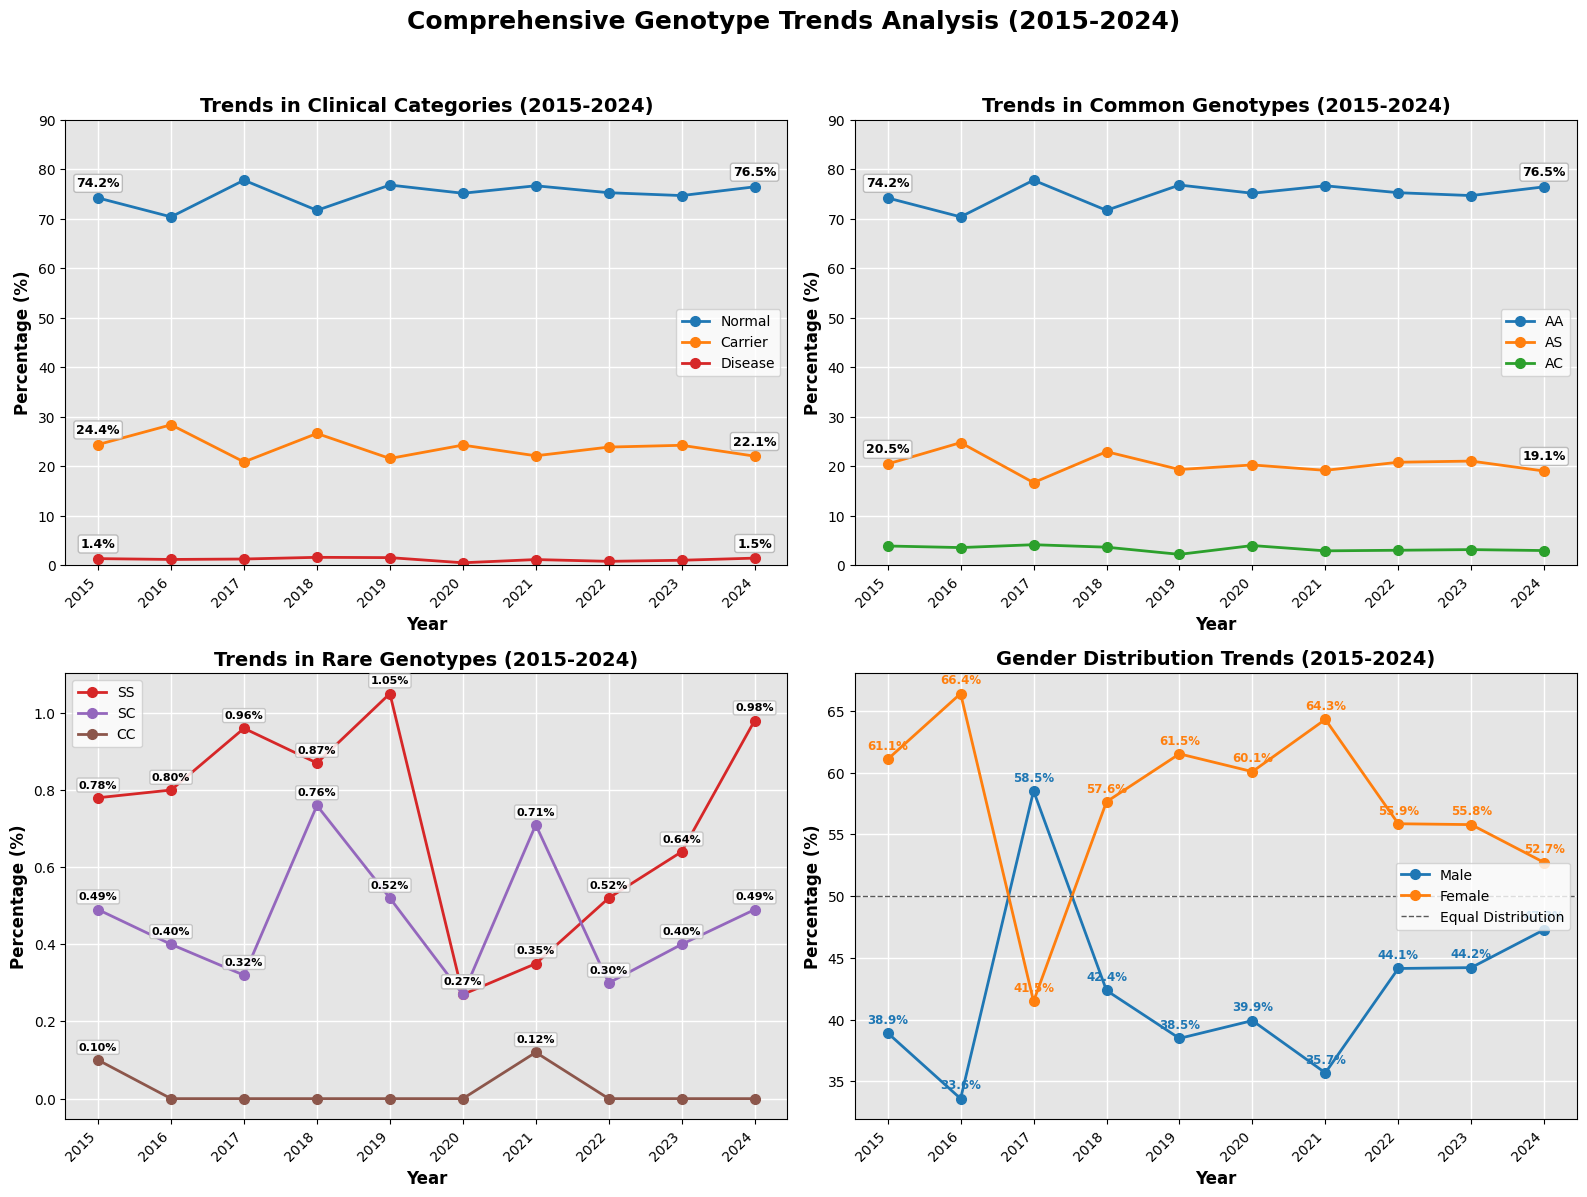

In [8]:
# Cell 8: Comprehensive composite (clinical, common, rare, gender)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comprehensive Genotype Trends Analysis (2015-2024)",
             fontsize=18, fontweight="bold", y=0.995)

# A: clinical categories
axA = axes[0, 0]
axA.set_facecolor("#e5e5e5")
for c in CLIN_ORDER:
    vals = clin_pct_year[c].reindex(YEARS).values
    axA.plot(YEARS, vals, marker="o", linewidth=2.0, markersize=7,
             color=CLIN_COLOR[c], label=c)
# label first and last value only
for c in CLIN_ORDER:
    vals = clin_pct_year[c].reindex(YEARS).values
    axA.annotate(f"{vals[0]:.1f}%", xy=(YEARS[0], vals[0]),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white",
                           ec="0.7", alpha=0.85))
    axA.annotate(f"{vals[-1]:.1f}%", xy=(YEARS[-1], vals[-1]),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white",
                           ec="0.7", alpha=0.85))
axA.set_title("Trends in Clinical Categories (2015-2024)", fontsize=14, fontweight="bold")
axA.set_xlabel("Year"); axA.set_ylabel("Percentage (%)")
axA.set_xticks(YEARS); plt.setp(axA.get_xticklabels(), rotation=45, ha="right")
axA.set_ylim(0, 90)
axA.legend(loc="center right")
axA.grid(True, color="white", linewidth=1)
axA.set_axisbelow(True)

# B: common genotypes (AA, AS, AC)
axB = axes[0, 1]
axB.set_facecolor("#e5e5e5")
for g in ["AA", "AS", "AC"]:
    vals = geno_pct_year[g].reindex(YEARS).values
    axB.plot(YEARS, vals, marker="o", linewidth=2.0, markersize=7,
             color=GENO_COLOR[g], label=g)
for g in ["AA", "AS"]:
    vals = geno_pct_year[g].reindex(YEARS).values
    axB.annotate(f"{vals[0]:.1f}%", xy=(YEARS[0], vals[0]),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white",
                           ec="0.7", alpha=0.85))
    axB.annotate(f"{vals[-1]:.1f}%", xy=(YEARS[-1], vals[-1]),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white",
                           ec="0.7", alpha=0.85))
axB.set_title("Trends in Common Genotypes (2015-2024)", fontsize=14, fontweight="bold")
axB.set_xlabel("Year"); axB.set_ylabel("Percentage (%)")
axB.set_xticks(YEARS); plt.setp(axB.get_xticklabels(), rotation=45, ha="right")
axB.set_ylim(0, 90)
axB.legend(loc="center right")
axB.grid(True, color="white", linewidth=1)
axB.set_axisbelow(True)

# C: rare genotypes (SS, SC, CC)
axC = axes[1, 0]
axC.set_facecolor("#e5e5e5")
for g in ["SS", "SC", "CC"]:
    vals = geno_pct_year[g].reindex(YEARS).values
    axC.plot(YEARS, vals, marker="o", linewidth=2.0, markersize=7,
             color=GENO_COLOR[g], label=g)
    for x, y in zip(YEARS, vals):
        if y > 0:
            axC.annotate(f"{y:.2f}%", xy=(x, y),
                         xytext=(0, 7), textcoords="offset points",
                         ha="center", fontsize=8, fontweight="bold",
                         bbox=dict(boxstyle="round,pad=0.18", fc="white",
                                   ec="0.75", alpha=0.85))
axC.set_title("Trends in Rare Genotypes (2015-2024)", fontsize=14, fontweight="bold")
axC.set_xlabel("Year"); axC.set_ylabel("Percentage (%)")
axC.set_xticks(YEARS); plt.setp(axC.get_xticklabels(), rotation=45, ha="right")
axC.legend(loc="upper left")
axC.grid(True, color="white", linewidth=1)
axC.set_axisbelow(True)

# D: gender distribution trend
axD = axes[1, 1]
axD.set_facecolor("#e5e5e5")
for s in ["Male", "Female"]:
    vals = sex_pct_year[s].reindex(YEARS).values
    axD.plot(YEARS, vals, marker="o", linewidth=2.0, markersize=7,
             color=SEX_COLOR[s], label=s)
    for x, y in zip(YEARS, vals):
        axD.annotate(f"{y:.1f}%", xy=(x, y),
                     xytext=(0, 7), textcoords="offset points",
                     ha="center", fontsize=8.5, fontweight="bold",
                     color=SEX_COLOR[s])
axD.axhline(50, color="0.35", linestyle="--", linewidth=1.0,
            label="Equal Distribution")
axD.set_title("Gender Distribution Trends (2015-2024)", fontsize=14, fontweight="bold")
axD.set_xlabel("Year"); axD.set_ylabel("Percentage (%)")
axD.set_xticks(YEARS); plt.setp(axD.get_xticklabels(), rotation=45, ha="right")
axD.legend(loc="center right")
axD.grid(True, color="white", linewidth=1)
axD.set_axisbelow(True)

fig.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(fig, "comprehensive_trends_analysis")
plt.show()

## Cell 9 - chi_square_sex_genotype.png

Saved: outputs/figures/chi_square_sex_genotype.png and .pdf


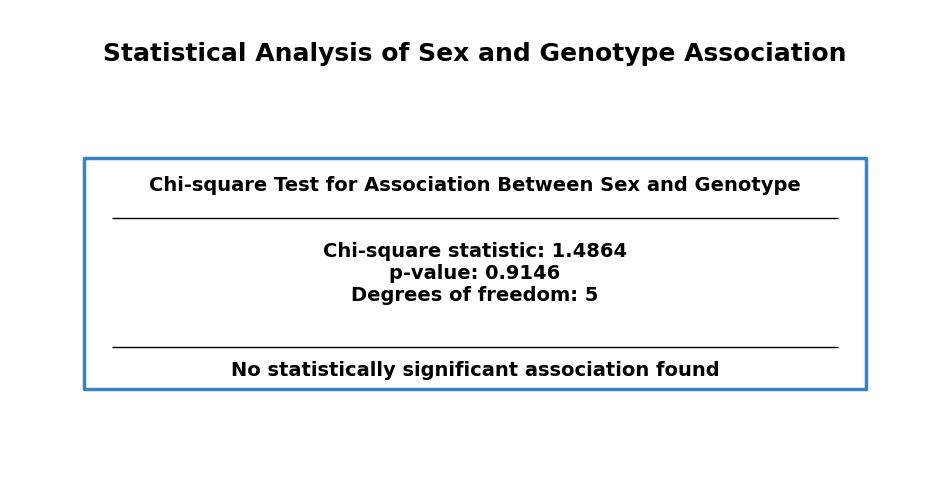

In [9]:
# Cell 9: Chi-square sex x genotype text panel
def chi_square_figure(chi_dict, title, header, edge_color, filename):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis("off")
    ax.text(0.5, 0.93, title, ha="center", va="top",
            fontsize=18, fontweight="bold", transform=ax.transAxes)

    body = (f"Chi-square statistic: {chi_dict['Chi_square_statistic']:.4f}\n"
            f"p-value: {chi_dict['p_value']:.4f}\n"
            f"Degrees of freedom: {chi_dict['Degrees_of_freedom']}")
    conclusion = chi_dict["Conclusion"]

    box_x, box_y, box_w, box_h = 0.08, 0.18, 0.84, 0.50
    rect = plt.Rectangle((box_x, box_y), box_w, box_h,
                         fill=False, edgecolor=edge_color, linewidth=2.5,
                         transform=ax.transAxes,
                         joinstyle="round")
    ax.add_patch(rect)

    ax.text(0.5, 0.62, header, ha="center", va="center",
            fontsize=14, fontweight="bold", transform=ax.transAxes)
    ax.hlines(0.55, box_x + 0.03, box_x + box_w - 0.03,
              transform=ax.transAxes, colors="black", linewidth=1)
    ax.text(0.5, 0.43, body, ha="center", va="center",
            fontsize=14, fontweight="bold", transform=ax.transAxes)
    ax.hlines(0.27, box_x + 0.03, box_x + box_w - 0.03,
              transform=ax.transAxes, colors="black", linewidth=1)
    ax.text(0.5, 0.22, conclusion, ha="center", va="center",
            fontsize=14, fontweight="bold", transform=ax.transAxes)

    save_figure(fig, filename)
    plt.show()

chi_square_figure(chi_geno,
                  title="Statistical Analysis of Sex and Genotype Association",
                  header="Chi-square Test for Association Between Sex and Genotype",
                  edge_color="#3a82c4",
                  filename="chi_square_sex_genotype")

## Cell 10 - chi_square_sex_clinical_category.png

Saved: outputs/figures/chi_square_sex_clinical_category.png and .pdf


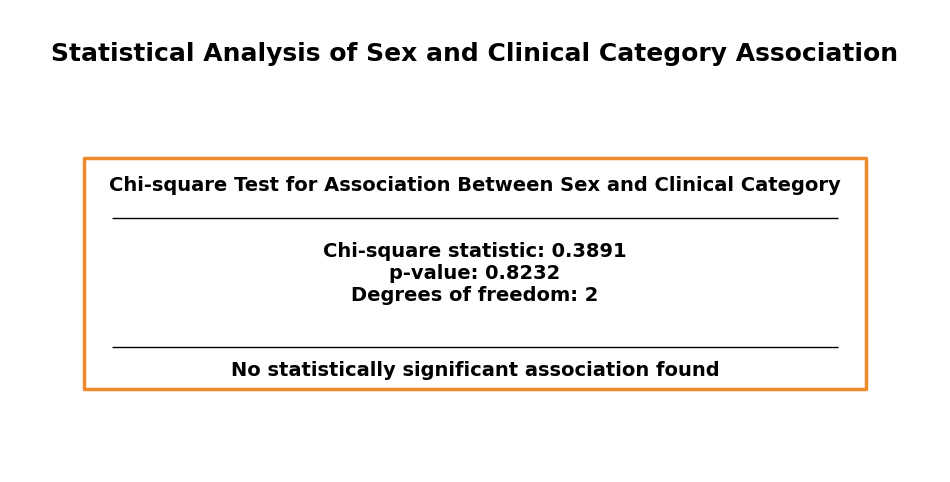

In [10]:
# Cell 10: Chi-square sex x clinical category text panel
chi_square_figure(chi_clin,
                  title="Statistical Analysis of Sex and Clinical Category Association",
                  header="Chi-square Test for Association Between Sex and Clinical Category",
                  edge_color="#ed8a2c",
                  filename="chi_square_sex_clinical_category")

## Cell 11 - statistical_summary.png

Saved: outputs/figures/statistical_summary.png and .pdf


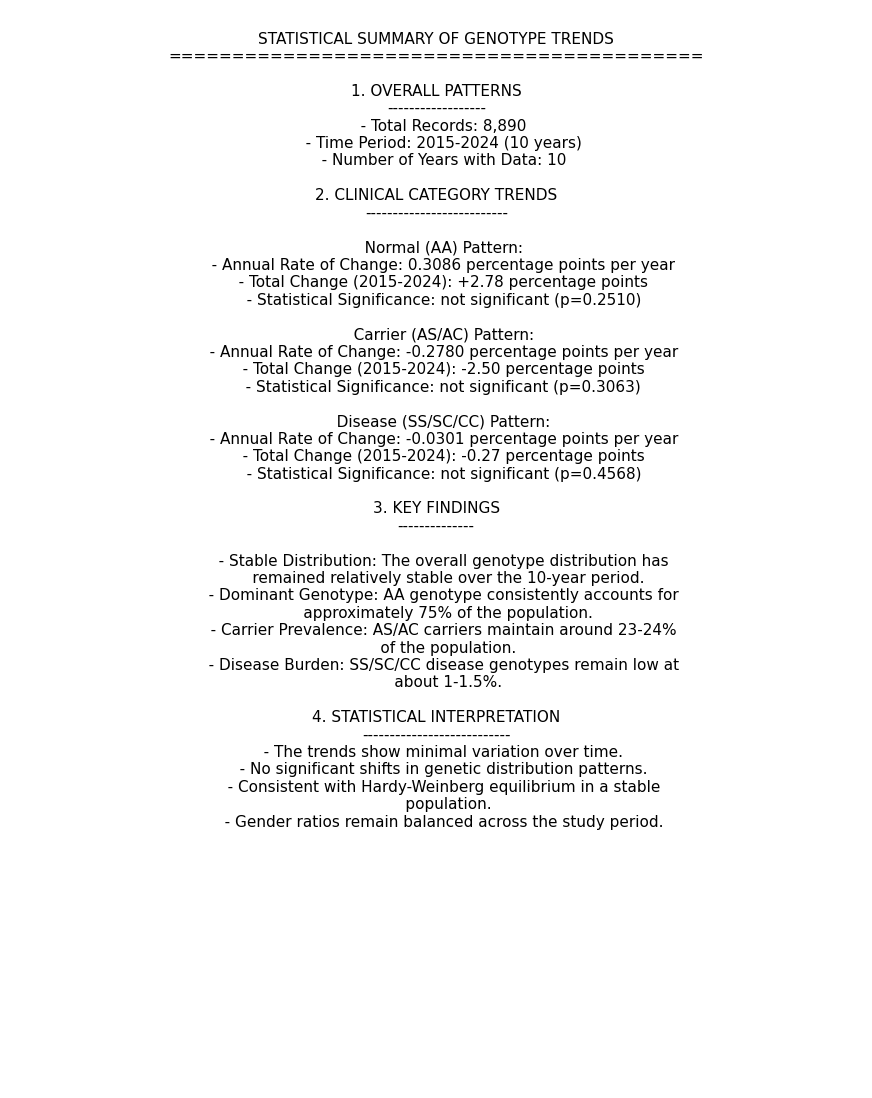

In [11]:
# Cell 11: Statistical summary text panel
fig, ax = plt.subplots(figsize=(11, 14))
ax.set_facecolor("#eeeeee")
ax.axis("off")

n_records = int(df.shape[0])

aa_row      = trend_results.set_index("Category").loc["HbAA"]
carrier_row = trend_results.set_index("Category").loc["Carrier (HbAS+HbAC)"]
disease_row = trend_results.set_index("Category").loc["Disease (HbSS+HbSC+HbCC)"]

def total_change(slope, years_span=9):
    return slope * years_span

aa_change      = total_change(aa_row["Slope_pp_per_year"])
carrier_change = total_change(carrier_row["Slope_pp_per_year"])
disease_change = total_change(disease_row["Slope_pp_per_year"])

txt = []
txt.append("STATISTICAL SUMMARY OF GENOTYPE TRENDS")
txt.append("=" * 42)
txt.append("")
txt.append("1. OVERALL PATTERNS")
txt.append("-" * 18)
txt.append(f"   - Total Records: {n_records:,}")
txt.append("   - Time Period: 2015-2024 (10 years)")
txt.append("   - Number of Years with Data: 10")
txt.append("")
txt.append("2. CLINICAL CATEGORY TRENDS")
txt.append("-" * 26)
txt.append("")
txt.append("   Normal (AA) Pattern:")
txt.append(f"   - Annual Rate of Change: {aa_row['Slope_pp_per_year']:.4f} percentage points per year")
txt.append(f"   - Total Change (2015-2024): {aa_change:+.2f} percentage points")
sig_label = "significant" if bool(aa_row["Significant_at_0.05"]) else "not significant"
txt.append(f"   - Statistical Significance: {sig_label} (p={aa_row['p_value']:.4f})")
txt.append("")
txt.append("   Carrier (AS/AC) Pattern:")
txt.append(f"   - Annual Rate of Change: {carrier_row['Slope_pp_per_year']:.4f} percentage points per year")
txt.append(f"   - Total Change (2015-2024): {carrier_change:+.2f} percentage points")
sig_label = "significant" if bool(carrier_row["Significant_at_0.05"]) else "not significant"
txt.append(f"   - Statistical Significance: {sig_label} (p={carrier_row['p_value']:.4f})")
txt.append("")
txt.append("   Disease (SS/SC/CC) Pattern:")
txt.append(f"   - Annual Rate of Change: {disease_row['Slope_pp_per_year']:.4f} percentage points per year")
txt.append(f"   - Total Change (2015-2024): {disease_change:+.2f} percentage points")
sig_label = "significant" if bool(disease_row["Significant_at_0.05"]) else "not significant"
txt.append(f"   - Statistical Significance: {sig_label} (p={disease_row['p_value']:.4f})")
txt.append("")
txt.append("3. KEY FINDINGS")
txt.append("-" * 14)
txt.append("")
txt.append("   - Stable Distribution: The overall genotype distribution has")
txt.append("     remained relatively stable over the 10-year period.")
txt.append("   - Dominant Genotype: AA genotype consistently accounts for")
txt.append("     approximately 75% of the population.")
txt.append("   - Carrier Prevalence: AS/AC carriers maintain around 23-24%")
txt.append("     of the population.")
txt.append("   - Disease Burden: SS/SC/CC disease genotypes remain low at")
txt.append("     about 1-1.5%.")
txt.append("")
txt.append("4. STATISTICAL INTERPRETATION")
txt.append("-" * 27)
txt.append("   - The trends show minimal variation over time.")
txt.append("   - No significant shifts in genetic distribution patterns.")
txt.append("   - Consistent with Hardy-Weinberg equilibrium in a stable")
txt.append("     population.")
txt.append("   - Gender ratios remain balanced across the study period.")

ax.text(0.5, 0.98, "\n".join(txt), ha="center", va="top",
        fontsize=11, family="DejaVu Sans", transform=ax.transAxes)

save_figure(fig, "statistical_summary")
plt.show()

## Summary

Trend regression and chi-square results are exported to `outputs/tables/`, and six statistical figures are saved to `outputs/figures/` using the project naming conventions.

The chi-square analyses yield χ² = 1.4864, p = 0.9146 for sex × genotype and χ² = 0.3891, p = 0.8232 for sex × clinical category, with no statistically significant associations observed.

**Next:** Notebook 05 performs the k-means clustering analysis and generates the corresponding clustering figures.
